# WCG+XBoost 实现81.4%

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# 读取数据
train = pd.read_csv("../titanic/train.csv")
test = pd.read_csv("../titanic/test.csv")

test['Survived'] = np.nan

data = pd.concat([train, test], ignore_index=True)

In [4]:
# 构造"Title"（人群类别: man, woman, boy）
data['Title'] = "man"
data.loc[data['Name'].str.contains("Master"),"Title"] = "boy"
data.loc[data["Sex"] == "female", "Title"] = "woman"

In [5]:
# 缺失值填充 - Age
fit_age = DecisionTreeRegressor(random_state=42)
age_features = ["Title","Pclass","SibSp","Parch"]

age_train = data[data['Age'].notna()][age_features]
y_age = data[data['Age'].notna()]["Age"]
X_age = pd.get_dummies(data=age_train, columns=['Title','Pclass'])
fit_age.fit(X_age, y_age)

age_test = data[data['Age'].isna()][age_features]
age_test = pd.get_dummies(data=age_test, columns=['Title','Pclass'])
X_age_test = age_test.reindex(columns=X_age.columns, fill_value=0)

data.loc[data["Age"].isna(), "Age"] = fit_age.predict(X_age_test)

In [6]:
# 缺失值补充 - Fare
fit_fare = DecisionTreeRegressor(random_state=42)
fare_train = data.loc[data["Fare"].notna(),
                      ["Fare", "Title", "Pclass", "Embarked", "Sex", "Age"]]
X_fare = pd.get_dummies(fare_train.drop("Fare", axis=1))
y_fare = fare_train["Fare"]
fit_fare.fit(X_fare, y_fare)

X_fare_missing = pd.get_dummies(
    data.loc[data["Fare"].isna(), ["Title", "Pclass", "Embarked", "Sex", "Age"]])
X_fare_missing = X_fare_missing.reindex(columns=X_fare.columns, fill_value=0)
data.loc[data["Fare"].isna(), "Fare"] = fit_fare.predict(X_fare_missing)

In [7]:
# 构造新特征
# 1. Ticket Freq
data['Ticket'] = data['Ticket'].astype(str).str.strip()
data['TicketFreq'] = data.groupby("Ticket")['Ticket'].transform("count")

# 2. 调整后的票价
data['FareAdj'] = data['Fare']/data['TicketFreq']

# 3. 家庭规模
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [8]:
data['FareAdj']

0        7.250000
1       35.641650
2        7.925000
3       26.550000
4        8.050000
          ...    
1304     8.050000
1305    36.300000
1306     7.250000
1307     8.050000
1308     7.452767
Name: FareAdj, Length: 1309, dtype: float64

In [9]:
# 筛选训练集的成年男性
# data 2
man_data = data[(data['PassengerId']<=891)&(data['Title']=="man")]

In [10]:
# 构造二维特征空间
# data 3

data_train = pd.DataFrame({
    'y': man_data['Survived'],
    'x1': man_data['Fare']/(man_data['TicketFreq']*10),
    "x2": man_data['FamilySize']+man_data["Age"]/70,
    "Pclass": man_data['Pclass']
})

用 XGBoost 在二维空间 (x1, x2) 上分类成年男性，并画出分类边界。

XGBoost 参数：
- objective="binary:logistic"：二分类。
- eval_metric = "error" : 评估指标=错误率
- max_depth = 5: 树的最大深度
- learning_rate = 0.1: 学习率

XGBoosting begun...


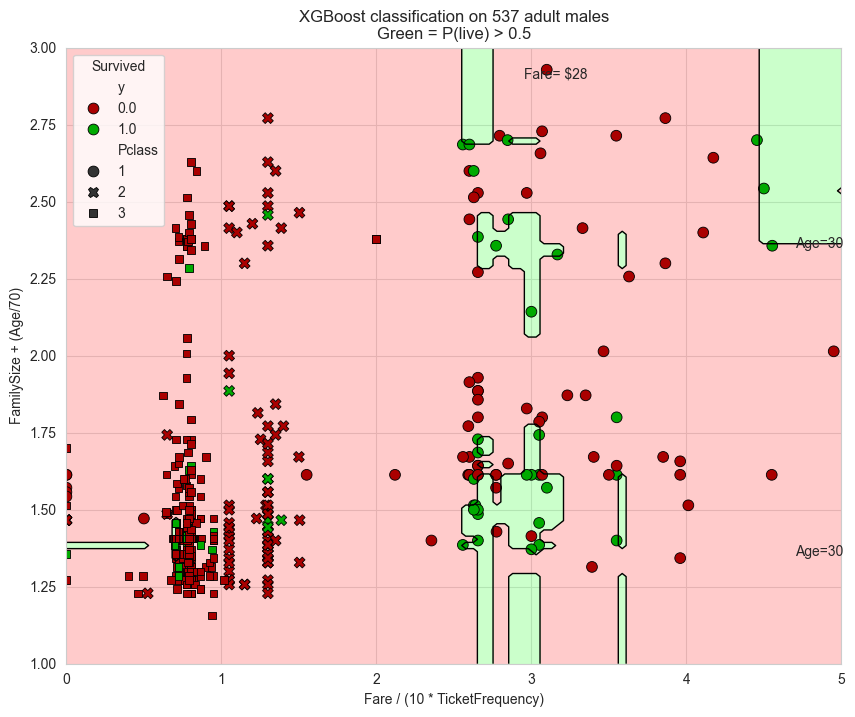

In [11]:
from xgboost import XGBClassifier

# 构建二维网格（x1, x2），用于画分类区域
x1s = np.linspace(0, 5, 100)
x2s = np.linspace(1,3,100)
xx1, xx2 = np.meshgrid(x1s, x2s)

# g 是存放所有网格点的 DataFrame，用来预测每个点的分类。
g = pd.DataFrame({"x1": xx1.ravel(),"x2":xx2.ravel()})

# 设置XGBoost参数
params = dict(
    objective = 'binary:logistic',
    eval_metric = "logloss",
    max_depth = 5,
    learning_rate = 0.1, # eta
    gamma = 0.1,
    colsample_bytree = 1,
    min_child_weight = 1,
    n_estimators = 500,
    random_state = 2,
    verbosity = 0,
    use_label_encoder = False
)

print("XGBoosting begun...")

# 训练 XGBoost 模型（只用成年男性数据集） data_train
X_train = data_train[['x1','x2']]
y_train = data_train['y'].astype(int)

model = XGBClassifier(**params)
model.fit(X_train, y_train)

# 对网格点预测，得到分类区域
p = model.predict_proba(g[['x1','x2']].values)[:,1]
g["y"] = (p>0.5).astype(int)

# 可视化分类结果
plt.figure(figsize=(10,8))

# 背景色 = 分类区域
# 用contourf画背景颜色（红色=死亡区域， 绿色=存活区域）
plt.contourf(xx1, xx2, g["y"].values.reshape(xx1.shape),levels=[-0.5,0.5,1.5], colors=["#FF9999",'#99FF99'], alpha=0.5)

# 等高线（决策边界）
# 用contour画黑色决策边界
plt.contour(xx1, xx2, g['y'].values.reshape(xx1.shape), levels=[0.5], colors='k', linewidths=1)

# 样本点
# 用散点图绘制真实样本点，颜色区分生存/死亡，形状区分Pclass
sns.scatterplot(data=data_train[(data_train['x1']<5)&(data_train['x2']<3)], x="x1", y="x2", hue="y", style="Pclass", palette={0:"#AA0000",1:"#00AA00"}, s=60, edgecolor="k")

# 装饰：虚线、注释
# 添加几条虚线（Fare=28, Age对应的参考线）
plt.axvline(2,8, linestyle='dotted', color='black')
plt.axhline(1,43, linestyle='dotted', color='black')
plt.axhline(2,43, linestyle='dotted', color='black')

plt.text(2.95, 2.9, "Fare= $28", fontsize=10)
plt.text(4.7, 2.35, "Age=30", fontsize=10)
plt.text(4.7, 1.35, "Age=30", fontsize=10)

plt.title("XGBoost classification on 537 adult males\nGreen = P(live) > 0.5")
plt.xlabel("Fare / (10 * TicketFrequency)")
plt.ylabel("FamilySize + (Age/70)")
plt.legend(title="Survived")
plt.xlim(0,5)
plt.ylim(1,3)
plt.show()


XGBoost训练出的分类器应用到成人男性数据集上，画出ROC曲线，并计算出AUC

XGBoost training....
AUC Score: 0.6233333333333334


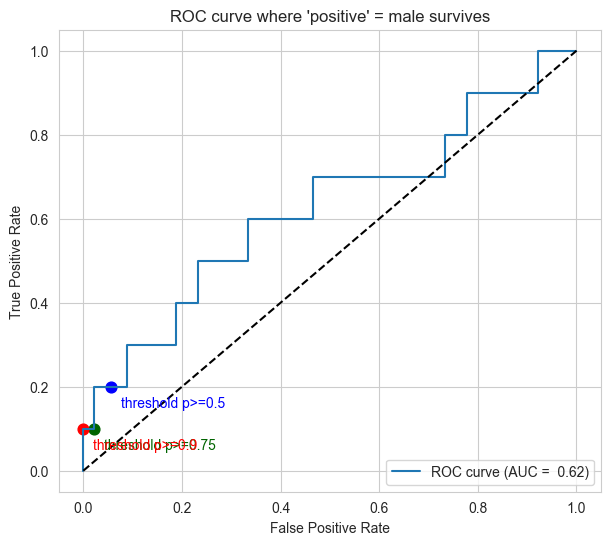

In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# 随机划分训练集和测试集
np.random.seed(300)
# idx = np.arange(537)
train_idx, test_idx = train_test_split(np.arange(len(data_train)), test_size=100, random_state=300)
# test_idx = np.random.choice(idx, size=100, replace=False)   # 测试集索引
# train_idx = np.setdiff1d(idx, test_idx)  # 训练集索引

data_train = data_train.reset_index(drop=True)

# 训练集
X_train = data_train.loc[train_idx,['x1','x2']]
y_train = data_train.loc[train_idx,['y']]
# 测试集
X_test = data_train.loc[test_idx,['x1','x2']]
y_test = data_train.loc[test_idx,['y']]

print("XGBoost training....")

xgb_model = XGBClassifier(
    **params
)

# 预测概率
xgb_model.fit(X_train, y_train)
p = xgb_model.predict_proba(X_test)[:,1]

# 生成ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, p)
auc_score = auc(fpr, tpr)

print(f"AUC Score: {auc_score}")

# 绘制 ROC曲线
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score: .2f})')
plt.plot([0,1],[0,1],'k--') # 对角线

# # 特定阈值点：0.5, 0.75, 0.9
for thr, color in zip([0.5, 0.75, 0.9],['blue','darkgreen','red']):
    # 找到离这个阈值最近的索引
    idx = np.argmin(np.abs(thresholds-thr))
    plt.scatter(fpr[idx], tpr[idx], color=color, s=60)
    plt.text(fpr[idx]+0.02, tpr[idx]-0.05, f"threshold p>={thr}", color=color)
#
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve where 'positive' = male survives")
plt.legend(loc='lower right')
plt.show()

Grid Search Cross Validation

In [13]:
# np.random.seed(2)
#
# trials = 100
# cv_sum = 0
#
# for i in range(trials):
#     # 随机抽样800个乘客作为训练集
#     train_idx = np.random.choice(range(891), 800, replace=False)
#     test_idx = np.setdiff1d(np.arange(891), train_idx)
#
#     # 训练集和测试集，只取Title=='man'
#     train = data[data['PassengerId'].isin(train_idx)&(data['Title']=='man')]
#     test = data[data['PassengerId'].isin(test_idx)&(data['Title']=='man')]
#
#     # 初始化预测列
#     data['Predict']= 0
#     # female 都预测为1
#     data.loc[data['Sex']=='female','Predict']=1
#
#     # 构造特征
#     dataTrain = pd.DataFrame({
#         'y': train['Survived'],
#         'x1': train['FareAdj']/10,
#         'x2': train['FamilySize']+train['Age']/70,
#     })
#
#     dataTest = pd.DataFrame({
#         'y': test['Survived'],
#         'x1': test['FareAdj']/10,
#         'x2': test['FamilySize']+test['Age']/70,
#         'PassengerId': test['PassengerId']
#     })
#
#     # 定义XGBoost 参数
#     model = XGBClassifier(**params)
#
#     # 训练模型
#     model.fit(dataTrain[['x1','x2']], dataTrain[['y']])
#
#     # 预测
#     pred = model.predict_proba(dataTest[['x1','x2']])[:,1]
#
#     # 应用阈值0.9转换成类别
#     dataTest['p'] = (pred>=0.9).astype(int)
#
#     # 更新预测结果
#     data.loc[dataTest['PassengerId'],"Predict"] = dataTest['p'].values
#
#     # 计算 CV 准确率
#     sm = np.sum(np.abs(data.loc[test_idx, "Predict"] - data.loc[test_idx, "Survived"]))
#     cv = 1 - sm / len(test_idx)
#
#     cv_sum += cv
#
# # 平均交叉验证准确率
# print(f"Average CV of {trials} trials = {cv_sum / trials:.4f}")


In [14]:
data['PassengerId']

0          1
1          2
2          3
3          4
4          5
        ... 
1304    1305
1305    1306
1306    1307
1307    1308
1308    1309
Name: PassengerId, Length: 1309, dtype: int64

In [18]:
np.random.seed(2)
trials = 100
cv_sum = 0

for i in range(trials):
    # 正确抽样
    train_ids = np.random.choice(data[data['PassengerId']<=891]['PassengerId'], 800, replace=False)
    test_ids = np.setdiff1d(data[data['PassengerId']<=891]['PassengerId'], train_ids)

    # 建立基线预测
    predict_all = pd.Series(0, index=data.index)
    predict_all.loc[data['Sex'] == 'female'] = 1

    # 提取男性训练/测试集
    train = data[(data['PassengerId'].isin(train_ids)) & (data['Title'] == 'man')]
    test = data[(data['PassengerId'].isin(test_ids)) & (data['Title'] == 'man')]

    # 特征
    X_train = pd.DataFrame({
        'x1': train['FareAdj'] / 10,
        'x2': train['FamilySize'] + train['Age'] / 70
    })
    y_train = train['Survived']

    X_test = pd.DataFrame({
        'x1': test['FareAdj'] / 10,
        'x2': test['FamilySize'] + test['Age'] / 70
    })

    # 训练
    model = XGBClassifier(
        **params
    )
    model.fit(X_train, y_train)

    # 预测
    p = model.predict_proba(X_test)[:, 1]
    preds = (p >= 0.9).astype(int)
    predict_all.loc[test.index] = preds

    # 计算准确率
    sm = np.abs(predict_all.loc[data['PassengerId'].isin(test_ids)] - data.loc[data['PassengerId'].isin(test_ids), 'Survived']).sum()
    cv = 1 - sm / len(test_ids)
    cv_sum += cv

print(f"Average CV of {trials} trials = {cv_sum / trials:.4f}")

Average CV of 100 trials = 0.7881


In [50]:

train = data[(data['PassengerId']<=891) & (data['Title'] == 'man')]
test = data[(data['PassengerId']>891) & (data['Title'] == 'man')]

predict_all = pd.DataFrame(test['PassengerId'])

X_train = pd.DataFrame({
        'x1': train['FareAdj'] / 10,
        'x2': train['FamilySize'] + train['Age'] / 70
    })

X_test = pd.DataFrame({
        'x1': test['FareAdj'] / 10,
        'x2': test['FamilySize'] + test['Age'] / 70
    })

y_train = train['Survived']

model = XGBClassifier(
        **params
    )
model.fit(X_train, y_train)
p = model.predict_proba(X_test)[:, 1]
predict_all['Survived'] = (p >= 0.5).astype(int)

In [51]:
predict_all

,PassengerId,Survived
891,892,0
893,894,0
894,895,0
896,897,0
898,899,0
...,...,...
1297,1298,0
1298,1299,0
1304,1305,0
1306,1307,0


In [52]:
truth = pd.read_csv('../titanic/truth.csv')

y_true = truth.loc[truth['PassengerId'].isin(predict_all['PassengerId']), 'Survived']

In [53]:
from sklearn.metrics import accuracy_score
accuracy_score(y_true, predict_all['Survived'])

0.7959183673469388

In [58]:
import pandas as pd
import xgboost as xgb
import numpy as np

# 假设 data 是你的 DataFrame
data = data.copy()

# 1. 训练集与测试集（仅成年男性）
dataB = data[(data["PassengerId"] <= 891) & (data["Title"] == "man")]
dataC = data[(data["PassengerId"] >= 892) & (data["Title"] == "man")]

# 2. 初始化预测列
data["Predict"] = 0
data.loc[data["Sex"] == "female", "Predict"] = 1

# 3. 特征工程
dataTrain = pd.DataFrame({
    "y": dataB["Survived"],
    "x1": dataB["FareAdj"] / 10,
    "x2": dataB["FamilySize"] + dataB["Age"] / 70
})

dataTest = pd.DataFrame({
    "y": dataC["Survived"],
    "x1": dataC["FareAdj"] / 10,
    "x2": dataC["FamilySize"] + dataC["Age"] / 70,
    "Pclass": dataC["Pclass"],
    "PassengerId": dataC["PassengerId"]
})

# 4. XGBoost 参数
params = {
    "objective": "binary:logistic",
    "eval_metric": "error",
    "max_depth": 5,
    "eta": 0.1,
    "gamma": 0.1,
    "colsample_bytree": 1,
    "min_child_weight": 1
}

# 5. 模型训练
dtrain = xgb.DMatrix(dataTrain[["x1", "x2"]], label=dataTrain["y"])
model = xgb.train(params, dtrain, num_boost_round=500)

# 6. 预测
dtest = xgb.DMatrix(dataTest[["x1", "x2"]])
p = model.predict(dtest)
dataTest["p"] = np.where(p >= 0.80, 1, 0)

# 7. 回填预测结果
data.loc[dataTest["PassengerId"], "Predict"] = dataTest["p"].values

# 8. 输出预测为幸存的男性
male_live = data[(data["Title"] == "man") & (data["Predict"] == 1)]
print(f"The following {len(male_live)} adult males are predicted to live:")
print(male_live[["PassengerId", "Pclass", "Name", "Age", "SibSp", "Parch", "FareAdj"]])

The following 5 adult males are predicted to live:
      PassengerId  Pclass                       Name        Age  SibSp  Parch  \
920           921       3          Samaan, Mr. Elias  26.250000      2      0   
942           943       2         Pulbaum, Mr. Franz  27.000000      0      0   
1036         1037       3  Vander Planke, Mr. Julius  31.000000      3      0   
1144         1145       3   Salander, Mr. Karl Johan  24.000000      0      0   
1223         1224       3        Thomas, Mr. Tannous  28.486328      0      0   

      FareAdj  
920    7.2264  
942   15.0333  
1036   9.0000  
1144   9.3250  
1223   7.2250  
